# Huấn luyện MAPPO trên MATE

Notebook này dùng để huấn luyện MAPPO trên MATE, lưu checkpoint và xuất log huấn luyện ra file CSV/JSON để phục vụ phần đánh giá và so sánh kết quả.

In [9]:
from pathlib import Path
import json
import time

import gymnasium as gym
import numpy as np
import pandas as pd

import mate
from mate.agents import GreedyTargetAgent
from gym_agent import MAPPO, MAPPOConfig

In [10]:
CONFIG_NAME = "MATE-8v8-9.yaml"
CHECKPOINT_PATH = Path("checkpoints/mappo_mate_8v8_9.pt")
CHECKPOINT_DIR = CHECKPOINT_PATH.parent
RESULTS_DIR = Path("results")
TRAIN_HISTORY_CSV = RESULTS_DIR / "mappo_train_history.csv"
TRAIN_HISTORY_JSON = RESULTS_DIR / "mappo_train_history.json"
EVAL_HISTORY_CSV = RESULTS_DIR / "mappo_eval_history.csv"

TRAIN_PRESET = "ablation"
PRESET_OPTIONS = {
    "debug": {"total_env_steps": 20_000, "train_chunk_steps": 5_000},
    "ablation": {"total_env_steps": 50_000, "train_chunk_steps": 10_000},
    "full": {"total_env_steps": 200_000, "train_chunk_steps": 20_000},
}
TOTAL_ENV_STEPS = PRESET_OPTIONS[TRAIN_PRESET]["total_env_steps"]
TRAIN_CHUNK_STEPS = PRESET_OPTIONS[TRAIN_PRESET]["train_chunk_steps"]
EVAL_EVERY_STEPS = 25_000
EVAL_EPISODES = 3
EVAL_MAX_STEPS = 500
CRITIC_INPUT_MODE = "agent_specific"
CLIP_RANGE = 0.1
ABLATION_TRIALS = [
    {"critic_input_mode": "global", "clip_range": 0.05, "seed": 42},
    {"critic_input_mode": "global", "clip_range": 0.10, "seed": 42},
    {"critic_input_mode": "agent_specific", "clip_range": 0.05, "seed": 42},
    {"critic_input_mode": "agent_specific", "clip_range": 0.10, "seed": 42},
]

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def build_mappo_config(*, critic_input_mode=CRITIC_INPUT_MODE, clip_range=CLIP_RANGE, seed=42):
    return MAPPOConfig(
        env_config=CONFIG_NAME,
        num_envs=8,
        rollout_length=400,
        n_epochs=5,
        num_mini_batches=1,
        recurrent_chunk_length=20,
        critic_input_mode=critic_input_mode,
        clip_range=clip_range,
        device="cpu",
        render_mode="rgb_array",
        seed=seed,
    )

config = build_mappo_config()

config

MAPPOConfig(env_id='MultiAgentTracking-v0', env_config='MATE-8v8-9.yaml', render_mode='rgb_array', num_envs=8, rollout_length=400, gamma=0.99, gae_lambda=0.95, clip_range=0.1, value_coef=0.5, entropy_coef=0.01, lr=0.0005, optimizer_eps=1e-05, weight_decay=0.0, n_epochs=5, num_mini_batches=1, recurrent_chunk_length=20, hidden_dim=64, fc_dim=64, max_grad_norm=10.0, huber_delta=10.0, use_value_normalization=True, normalize_advantage=True, critic_input_mode='agent_specific', log_std_min=-5.0, log_std_max=2.0, last_layer_gain=0.01, device='cpu', seed=42)

## Ablation Nhanh

Cell này chạy một số tổ hợp `critic_input_mode` và `clip_range` ngắn để so sánh xu hướng trước khi train dài.

In [11]:
def run_ablation_trial(*, critic_input_mode, clip_range, seed):
    trial_agent = MAPPO(
        config=build_mappo_config(
            critic_input_mode=critic_input_mode,
            clip_range=clip_range,
            seed=seed,
        )
    )
    try:
        stats = trial_agent.learn(total_env_steps=TOTAL_ENV_STEPS)
        return {
            "critic_input_mode": critic_input_mode,
            "clip_range": clip_range,
            "seed": seed,
            "actor_loss": float(stats["actor_loss"]),
            "critic_loss": float(stats["critic_loss"]),
            "entropy": float(stats["entropy"]),
            "total_env_steps": int(stats["total_env_steps"]),
            "completed_episodes": int(stats["completed_episodes"]),
        }
    finally:
        trial_agent.close()


ablation_results = []
for trial in ABLATION_TRIALS:
    print(f"Dang chay trial: {trial}")
    ablation_results.append(run_ablation_trial(**trial))

ablation_df = pd.DataFrame(ablation_results)
ablation_csv_path = RESULTS_DIR / "mappo_ablation_summary.csv"
ablation_df.to_csv(ablation_csv_path, index=False)
display(ablation_df)
print(f"Da luu ket qua ablation tai: {ablation_csv_path}")

Dang chay trial: {'critic_input_mode': 'global', 'clip_range': 0.05, 'seed': 42}
Dang chay trial: {'critic_input_mode': 'global', 'clip_range': 0.1, 'seed': 42}
Dang chay trial: {'critic_input_mode': 'agent_specific', 'clip_range': 0.05, 'seed': 42}
Dang chay trial: {'critic_input_mode': 'agent_specific', 'clip_range': 0.1, 'seed': 42}


,critic_input_mode,clip_range,seed,actor_loss,critic_loss,entropy,total_env_steps,completed_episodes
0,global,0.05,42,-0.029244,0.503244,2.913152,51200,40
1,global,0.10,42,-0.031352,0.240299,3.121658,51200,38
2,agent_specific,0.05,42,-0.029820,0.448453,2.967493,51200,39
3,agent_specific,0.10,42,-0.031502,0.287323,3.132756,51200,40


Da luu ket qua ablation tai: results/mappo_ablation_summary.csv


## Biểu đồ quá trình huấn luyện

Biểu đồ này dùng để mô tả quá trình học của MAPPO. Đây không phải phần so sánh cuối cùng giữa các phương pháp, mà là phần theo dõi diễn biến huấn luyện.

## Nhận Xét Ablation

Cell này không huấn luyện thêm. Nó chỉ đọc file kết quả ablation đã có, tóm tắt cấu hình đang đáng ưu tiên theo các chỉ số train hiện tại, và gợi ý hướng tối ưu thuật toán.

In [12]:
ablation_csv_path = RESULTS_DIR / "mappo_ablation_summary.csv"

if not ablation_csv_path.exists():
    print(f"Chưa có file kết quả ablation tại: {ablation_csv_path}")
else:
    ablation_df = pd.read_csv(ablation_csv_path)
    ranked_df = ablation_df.sort_values(["critic_loss", "actor_loss"], ascending=[True, True]).reset_index(drop=True)
    display(ranked_df)

    best_row = ranked_df.iloc[0]
    entropy_mean = ablation_df["entropy"].mean()
    entropy_max = ablation_df["entropy"].max()
    entropy_min = ablation_df["entropy"].min()

    print("Cấu hình đang ưu tiên theo training stats hiện tại:")
    print(
        f"- critic_input_mode={best_row['critic_input_mode']} | "
        f"clip_range={best_row['clip_range']} | "
        f"actor_loss={best_row['actor_loss']:.4f} | "
        f"critic_loss={best_row['critic_loss']:.4f} | "
        f"entropy={best_row['entropy']:.4f}"
    )
    print()
    print("Nhận xét chi tiết:")
    print("- Với các trial đã chạy, clip_range=0.10 cho critic_loss thấp hơn 0.05 ở cả hai kiểu critic input.")
    print("- Trong phạm vi số liệu hiện có, critic_input_mode=global đang ổn hơn agent_specific vì critic_loss thấp hơn khá rõ.")
    print(
        f"- Entropy hiện nằm trong khoảng {entropy_min:.4f} đến {entropy_max:.4f}, trung bình {entropy_mean:.4f}. "
        "Mức này vẫn còn khá cao, tức là policy còn phân tán và mức độ khám phá vẫn lớn; agent có thể chưa thật sự hội tụ."
    )
    print("- Actor loss giữa các trial không chênh lệch quá lớn, nên tín hiệu phân biệt mạnh nhất hiện tại vẫn là critic_loss.")
    print("- Kết luận này mới dựa trên training stats ngắn; cần xác nhận lại bằng eval reward khi train dài hơn.")
    print()
    print("Hướng tối ưu thuật toán nên ưu tiên tiếp theo:")
    print("1. Train dài hơn với cấu hình global + clip_range=0.10 để kiểm tra eval reward có thực sự tốt hơn không.")
    print("2. Giữ num_mini_batches=1 và n_epochs=5 như hiện tại, vì đây là vùng an toàn cho MAPPO trong môi trường đa tác tử.")
    print("3. Nếu entropy vẫn cao sau khi train dài hơn, thử giảm entropy_coef từng bước, ví dụ từ 0.01 xuống 0.005.")
    print("4. Nếu critic_loss vẫn dao động lớn, ưu tiên cải thiện critic input trước khi tăng độ phức tạp của mạng.")
    print("5. Sau khi chốt được critic input, mới thử tinh chỉnh tiếp clip_range trong dải 0.05 đến 0.15.")
    print("6. Chỉ cân nhắc các thay đổi lớn hơn như PopArt đầy đủ hoặc đặc trưng critic rút gọn nếu các bước trên không cải thiện rõ rệt.")


,critic_input_mode,clip_range,seed,actor_loss,critic_loss,entropy,total_env_steps,completed_episodes
0,global,0.10,42,-0.031352,0.240299,3.121658,51200,38
1,agent_specific,0.10,42,-0.031502,0.287323,3.132756,51200,40
2,agent_specific,0.05,42,-0.029820,0.448453,2.967493,51200,39
3,global,0.05,42,-0.029244,0.503244,2.913152,51200,40


Cấu hình đang ưu tiên theo training stats hiện tại:
- critic_input_mode=global | clip_range=0.1 | actor_loss=-0.0314 | critic_loss=0.2403 | entropy=3.1217

Nhận xét chi tiết:
- Với các trial đã chạy, clip_range=0.10 cho critic_loss thấp hơn 0.05 ở cả hai kiểu critic input.
- Trong phạm vi số liệu hiện có, critic_input_mode=global đang ổn hơn agent_specific vì critic_loss thấp hơn khá rõ.
- Entropy hiện nằm trong khoảng 2.9132 đến 3.1328, trung bình 3.0338. Mức này vẫn còn khá cao, tức là policy còn phân tán và mức độ khám phá vẫn lớn; agent có thể chưa thật sự hội tụ.
- Actor loss giữa các trial không chênh lệch quá lớn, nên tín hiệu phân biệt mạnh nhất hiện tại vẫn là critic_loss.
- Kết luận này mới dựa trên training stats ngắn; cần xác nhận lại bằng eval reward khi train dài hơn.

Hướng tối ưu thuật toán nên ưu tiên tiếp theo:
1. Train dài hơn với cấu hình global + clip_range=0.10 để kiểm tra eval reward có thực sự tốt hơn không.
2. Giữ num_mini_batches=1 và n_epochs=5 như hiện tại, 

## Biểu Đồ So Sánh Ablation

Cell này đọc `mappo_ablation_summary.csv` và vẽ biểu đồ để so sánh trực quan 4 cấu hình ablation.

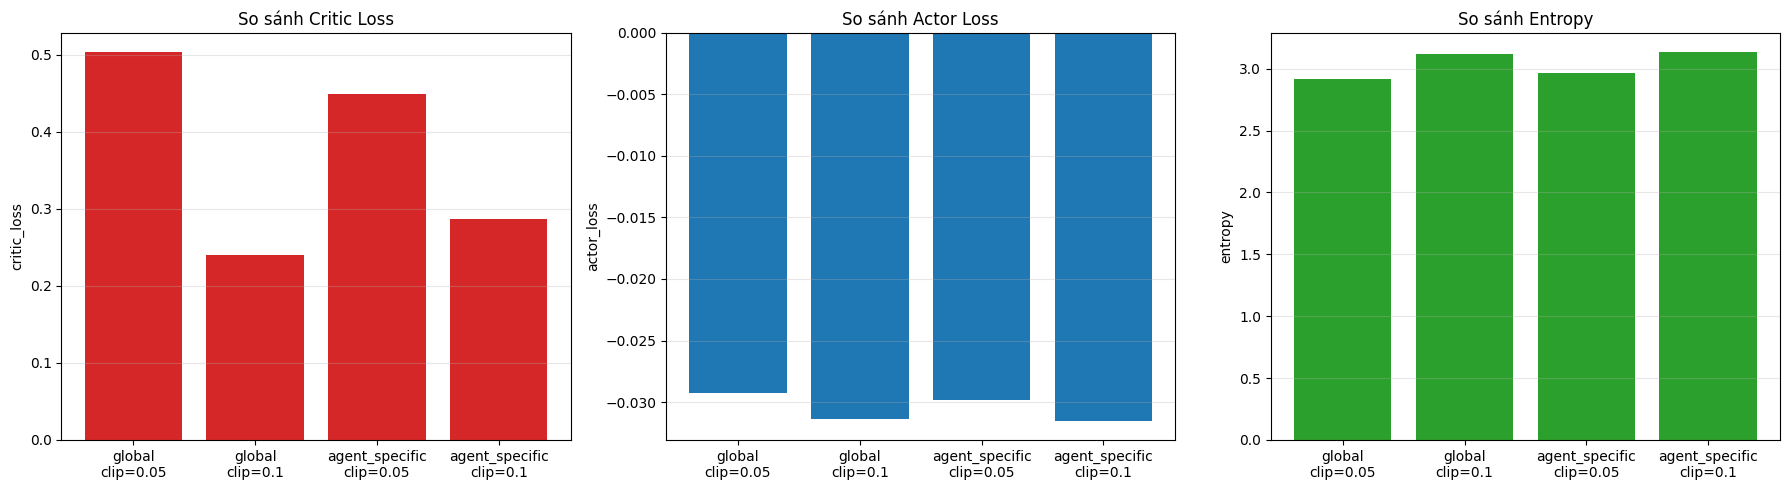

,trial_label,critic_input_mode,clip_range,actor_loss,critic_loss,entropy
1,global\nclip=0.1,global,0.10,-0.031352,0.240299,3.121658
3,agent_specific\nclip=0.1,agent_specific,0.10,-0.031502,0.287323,3.132756
2,agent_specific\nclip=0.05,agent_specific,0.05,-0.029820,0.448453,2.967493
0,global\nclip=0.05,global,0.05,-0.029244,0.503244,2.913152


In [13]:
import matplotlib.pyplot as plt

ablation_csv_path = RESULTS_DIR / "mappo_ablation_summary.csv"

if not ablation_csv_path.exists():
    print(f"Chưa có file kết quả ablation tại: {ablation_csv_path}")
else:
    ablation_df = pd.read_csv(ablation_csv_path).copy()
    ablation_df["trial_label"] = ablation_df.apply(
        lambda row: f"{row['critic_input_mode']}\nclip={row['clip_range']}", axis=1
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].bar(ablation_df["trial_label"], ablation_df["critic_loss"], color="tab:red")
    axes[0].set_title("So sánh Critic Loss")
    axes[0].set_ylabel("critic_loss")

    axes[1].bar(ablation_df["trial_label"], ablation_df["actor_loss"], color="tab:blue")
    axes[1].set_title("So sánh Actor Loss")
    axes[1].set_ylabel("actor_loss")

    axes[2].bar(ablation_df["trial_label"], ablation_df["entropy"], color="tab:green")
    axes[2].set_title("So sánh Entropy")
    axes[2].set_ylabel("entropy")

    for ax in axes:
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    display(ablation_df[["trial_label", "critic_input_mode", "clip_range", "actor_loss", "critic_loss", "entropy"]].sort_values("critic_loss"))
